# 02 — Modelado

Entrenamiento y evaluación de modelos de clasificación multiclase ordinal para predecir el **tier de sala** de artistas de rap/urbano en España.

**Variable objetivo**: `nivel` → {1: bajo, 2: medio, 3: alto}  
**Tamaño del dataset**: 182 artistas  
**Clases**: bajo (81), medio (62), alto (39)

## Modelos evaluados

| Modelo | Modo features | Justificación |
|--------|--------------|---------------|
| Dummy (most_frequent) | — | Baseline mínimo |
| Dummy (stratified) | — | Baseline aleatorio estratificado |
| Regresión Logística | lineal (RobustScaler) | Interpretable, bueno para clase ordinal |
| SVM (RBF) | lineal (RobustScaler) | Kernel no lineal, robusto con escalado |
| Random Forest | arbol (sin escalar) | Ensemble robusto, feature importance |
| XGBoost | arbol (sin escalar) | Gradient boosting, suele ganar en tabular |
| Regresión Ordinal (mord) | lineal (RobustScaler) | Cumulative link model, explota la ordinalidad del target |
| LightGBM | arbol (sin escalar) | Gradient boosting alternativo, más estable que XGBoost |

## Estrategia de validación

Se usa **StratifiedKFold k=5** en lugar de un train/test split clásico. Con n=182 artistas, un hold-out del 20% dejaría solo ~36 artistas de test — demasiado poco para estimar métricas fiables.

Con CV k=5 el dataset se divide en 5 particiones de ~36 artistas. Cada artista aparece exactamente **una vez en test**, evaluado por un modelo que **no lo ha visto durante el entrenamiento** — no hay data leakage. Las métricas reportadas son la media de los 5 folds.

> **Caveat**: con n=182 la desviación estándar del CV sigue siendo notable (~±5-10 puntos). Diferencias pequeñas entre modelos no son estadísticamente significativas.

- **Métricas**: accuracy + F1 macro (trata igual las 3 clases independientemente del tamaño)
- **`class_weight='balanced'`** en modelos que lo admiten: compensa el desbalanceo (alto ~39 vs bajo/medio ~70+)
- **Semilla fija** (`random_state=42`) para reproducibilidad

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from src.features.preprocess import cargar_datos

# Carpeta de figuras — se crea si no existe
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

SEED    = 42
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['accuracy', 'f1_macro']

LABEL_MAP = {1: 'bajo', 2: 'medio', 3: 'alto'}
CLASES    = ['bajo', 'medio', 'alto']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


## 2. Cargar datos

In [2]:
X_arbol,  y, feat_arbol  = cargar_datos(modo='arbol')
X_lineal, _, feat_lineal = cargar_datos(modo='lineal')

print(f'X_arbol : {X_arbol.shape}   ({len(feat_arbol)} features, sin escalar)')
print(f'X_lineal: {X_lineal.shape}  ({len(feat_lineal)} features, RobustScaler)')
print(f'y       : {y.shape}')
print(f'\nDistribución del target:')
print(y.map(LABEL_MAP).value_counts().reindex(CLASES))

X_arbol : (182, 32)   (32 features, sin escalar)
X_lineal: (182, 24)  (24 features, RobustScaler)
y       : (182,)

Distribución del target:
target
bajo     81
medio    62
alto     39
Name: count, dtype: int64


## 3. Función de evaluación

Encapsula la validación cruzada y devuelve un resumen de métricas.

In [3]:
def evaluar_modelo(nombre, modelo, X, y, cv=CV, scoring=SCORING):
    """Evalúa un modelo con CV estratificado. Devuelve dict de resultados."""
    res = cross_validate(modelo, X, y, cv=cv, scoring=scoring, return_train_score=False)
    acc_mean  = res['test_accuracy'].mean()
    acc_std   = res['test_accuracy'].std()
    f1_mean   = res['test_f1_macro'].mean()
    f1_std    = res['test_f1_macro'].std()
    print(f'{nombre:<30}  acc={acc_mean:.3f}±{acc_std:.3f}  f1_macro={f1_mean:.3f}±{f1_std:.3f}')
    return {
        'nombre': nombre,
        'acc_mean': acc_mean, 'acc_std': acc_std,
        'f1_mean':  f1_mean,  'f1_std':  f1_std,
    }

resultados = []

## 4. Baselines

Los baselines son el **suelo mínimo** que cualquier modelo real debe superar. Se usan dos estrategias de `DummyClassifier` que no aprenden nada de los datos:

| Baseline | Estrategia | Accuracy | ¿Para qué sirve? |
|----------|-----------|----------|-----------------|
| `most_frequent` | Siempre predice `bajo` (clase mayoritaria, 81/182) | 44.5% | Umbral más exigente: si no lo superas, el modelo es inútil |
| `stratified` | Predice aleatoriamente respetando la distribución de clases | ~38% | Confirma que el modelo no se limita a seguir la distribución |

> Si siempre dices "este artista es de sala pequeña" aciertas el 44.5% de las veces sin aprender nada. Cualquier modelo útil debe superar ese valor claramente.

In [4]:
print(f'{"Modelo":<30}  {"Accuracy":>14}  {"F1 macro":>14}')
print('-' * 64)
resultados.append(evaluar_modelo(
    'Dummy (most_frequent)',
    DummyClassifier(strategy='most_frequent', random_state=SEED),
    X_arbol, y
))
resultados.append(evaluar_modelo(
    'Dummy (stratified)',
    DummyClassifier(strategy='stratified', random_state=SEED),
    X_arbol, y
))

Modelo                                Accuracy        F1 macro
----------------------------------------------------------------
Dummy (most_frequent)           acc=0.445±0.009  f1_macro=0.205±0.003
Dummy (stratified)              acc=0.384±0.083  f1_macro=0.314±0.060


## 5. Regresión Logística

Modelo lineal interpretable. Usa `X_lineal` (23 features, RobustScaler aplicado en `preprocess.py`).
- `solver='lbfgs'`: maneja multiclase automáticamente desde scikit-learn 1.5 (parámetro `multi_class` eliminado).
- `class_weight='balanced'`: ajusta pesos inversamente proporcionales a la frecuencia de cada clase.

In [5]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
)
resultados.append(evaluar_modelo('Regresión Logística', lr, X_lineal, y))

Regresión Logística             acc=0.594±0.075  f1_macro=0.563±0.081


## 6. SVM con kernel RBF

Modelo de márgenes máximos con kernel radial. Sensible al escalado → usa `X_lineal`.
- `kernel='rbf'`: captura relaciones no lineales entre features.
- `class_weight='balanced'`: penaliza más los errores en clases minoritarias.

In [6]:
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=SEED,
)
resultados.append(evaluar_modelo('SVM (RBF)', svm, X_lineal, y))

SVM (RBF)                       acc=0.648±0.076  f1_macro=0.623±0.080


## 7. Random Forest

Ensemble de árboles de decisión con bagging. Usa `X_arbol` (31 features, sin escalar).
- `n_estimators=300`: número de árboles. Más árboles = menos varianza, pero rendimiento marginal decreciente.
- `max_features='sqrt'`: en cada split considera √31 ≈ 6 features — reduce correlación entre árboles.
- `class_weight='balanced_subsample'`: pesos balanceados recalculados en cada subsample del bootstrap.

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)
resultados.append(evaluar_modelo('Random Forest', rf, X_arbol, y))

Random Forest                   acc=0.616±0.032  f1_macro=0.585±0.035


## 8. XGBoost

Gradient boosting con regularización. Suele dar los mejores resultados en datos tabulares.
- `objective='multi:softprob'`: clasificación multiclase con probabilidades por clase.
- `scale_pos_weight`: no aplica en multiclase — usamos `sample_weight` vía `fit_params` (ignorado en cross_validate simple). XGBoost es razonablemente robusto al desbalanceo leve.
- `eval_metric='mlogloss'`: función de pérdida multiclase logarítmica.
- XGBoost espera clases 0-indexed: convertimos y→{0,1,2}.

In [8]:
y_xgb = y - 1  # XGBoost necesita clases 0-indexed: {0=bajo, 1=medio, 2=alto}

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)
resultados.append(evaluar_modelo('XGBoost', xgb, X_arbol, y_xgb))

XGBoost                         acc=0.632±0.039  f1_macro=0.603±0.037


## 9. Regresión Ordinal (mord)

Modelo diseñado explícitamente para targets ordinales. A diferencia de la regresión logística multiclase estándar, asume que existe un **orden natural entre las clases**: bajo < medio < alto.

- `LogisticIT` (*Immediate Threshold*): modela umbrales acumulativos entre clases consecutivas. Penaliza más el error `bajo → alto` (dos saltos) que `bajo → medio` (un salto).
- `alpha=1.0`: regularización L2 equivalente a `C=1` en sklearn.
- No soporta `class_weight` — desventaja frente a los otros modelos.
- Usa `X_lineal` (RobustScaler) al ser un modelo de regresión generalizada.

> Si no está instalado: `pip install mord`

In [9]:
from mord import LogisticIT

# LogisticIT: cumulative link model — modela umbrales acumulativos entre clases consecutivas.
# Penaliza más el error bajo→alto (2 saltos) que bajo→medio (1 salto).
ordinal = LogisticIT(alpha=1.0)
resultados.append(evaluar_modelo('Regresión Ordinal (mord)', ordinal, X_lineal, y))

Regresión Ordinal (mord)        acc=0.604±0.049  f1_macro=0.564±0.045


## 10. LightGBM

Alternativa directa a XGBoost basada en *Leaf-wise tree growth*. En datasets pequeños suele ser más estable (menor varianza de CV) con precisión comparable.

- `objective='multiclass'`: clasificación multiclase nativa.
- `class_weight='balanced'`: misma estrategia que RF y SVM.
- Mismos hiperparámetros base que XGBoost para comparación justa.
- Usa `X_arbol` (sin escalar) como el resto de modelos de árbol.

In [10]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
)
resultados.append(evaluar_modelo('LightGBM', lgbm, X_arbol, y))

LightGBM                        acc=0.610±0.057  f1_macro=0.576±0.050


## 11. Tabla comparativa

In [11]:
df_res = pd.DataFrame(resultados)
df_res['acc_display'] = df_res.apply(lambda r: f"{r.acc_mean:.3f} ± {r.acc_std:.3f}", axis=1)
df_res['f1_display']  = df_res.apply(lambda r: f"{r.f1_mean:.3f} ± {r.f1_std:.3f}",  axis=1)

display_cols = ['nombre', 'acc_display', 'f1_display']
tabla = df_res[display_cols].rename(columns={
    'nombre': 'Modelo',
    'acc_display': 'Accuracy (CV5)',
    'f1_display': 'F1 macro (CV5)',
}).set_index('Modelo')

print('\nResultados — StratifiedKFold k=5')
print('=' * 55)
print(tabla.to_string())


Resultados — StratifiedKFold k=5
                         Accuracy (CV5) F1 macro (CV5)
Modelo                                                
Dummy (most_frequent)     0.445 ± 0.009  0.205 ± 0.003
Dummy (stratified)        0.384 ± 0.083  0.314 ± 0.060
Regresión Logística       0.594 ± 0.075  0.563 ± 0.081
SVM (RBF)                 0.648 ± 0.076  0.623 ± 0.080
Random Forest             0.616 ± 0.032  0.585 ± 0.035
XGBoost                   0.632 ± 0.039  0.603 ± 0.037
Regresión Ordinal (mord)  0.604 ± 0.049  0.564 ± 0.045
LightGBM                  0.610 ± 0.057  0.576 ± 0.050


## 12. Visualización — Comparativa de modelos

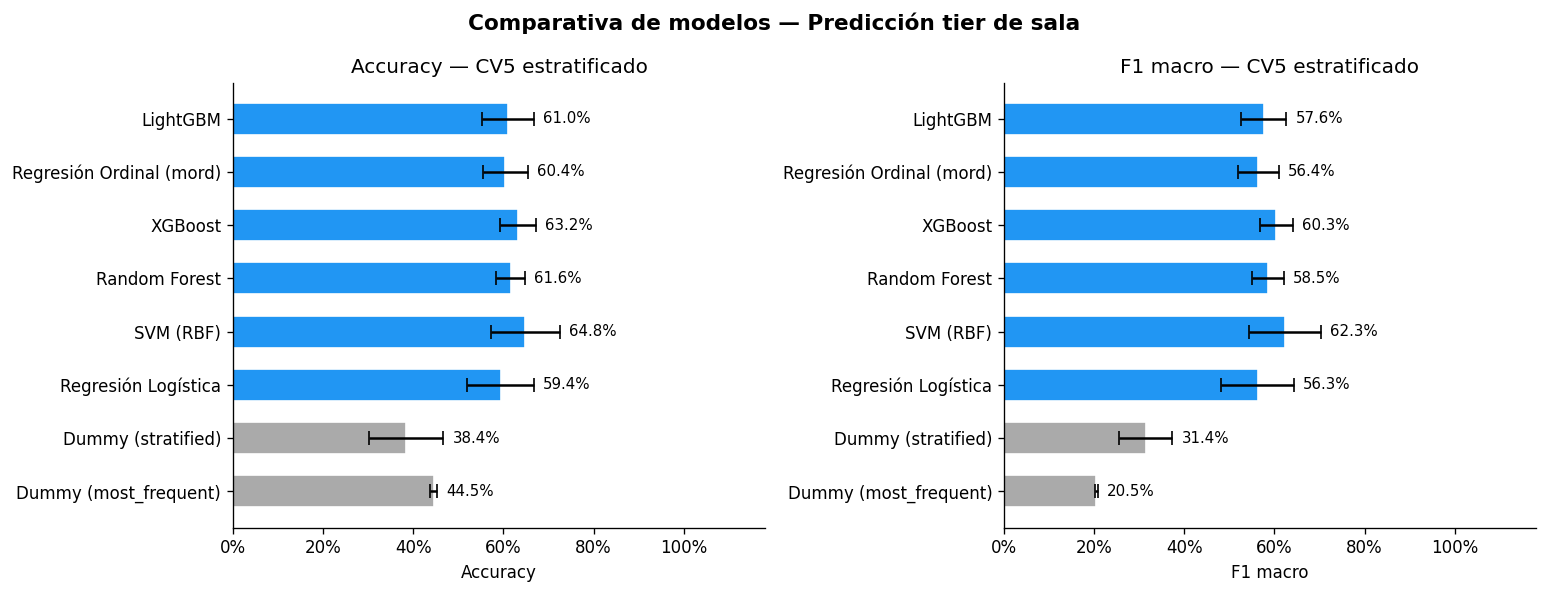

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, label in [
    (axes[0], 'acc',  'Accuracy'),
    (axes[1], 'f1',   'F1 macro'),
]:
    colores = ['#aaa' if 'Dummy' in n else '#2196F3' for n in df_res['nombre']]
    bars = ax.barh(
        df_res['nombre'],
        df_res[f'{metrica}_mean'],
        xerr=df_res[f'{metrica}_std'],
        color=colores,
        edgecolor='white',
        capsize=4,
        height=0.6,
    )
    ax.set_xlabel(label)
    ax.set_title(f'{label} — CV5 estratificado')
    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    for bar, val, std in zip(bars, df_res[f'{metrica}_mean'], df_res[f'{metrica}_std']):
        ax.text(val + std + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=9)

plt.suptitle('Comparativa de modelos — Predicción tier de sala', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/comparativa_modelos.png', bbox_inches='tight')
plt.show()

## 13. Matriz de confusión — predicciones out-of-fold

Usamos `cross_val_predict` para obtener predicciones **out-of-fold (OOF)**: cada artista es predicho por un modelo que NO lo ha visto durante el entrenamiento. Esto da una estimación honesta del comportamiento real del modelo, equivalente a las métricas de CV.

> No se usa train/test split clásico porque con n=182 un hold-out del 20% dejaría solo ~36 artistas de test — demasiado poco para estimar métricas fiables. El CV estratificado k=5 es la estrategia estándar para datasets pequeños.

In [13]:
mejor = df_res.loc[df_res['f1_mean'].idxmax(), 'nombre']
print(f'Mejor modelo: {mejor}')

# Predicciones OOF: cada artista predicho por un modelo que no lo vio en train
if mejor == 'XGBoost':
    y_oof = cross_val_predict(xgb, X_arbol, y_xgb, cv=CV)
    y_true_display = pd.Series(y_xgb.values).map({0: 'bajo', 1: 'medio', 2: 'alto'})
    y_pred_display = pd.Series(y_oof).map({0: 'bajo', 1: 'medio', 2: 'alto'})
elif mejor in ('Regresión Logística', 'SVM (RBF)'):
    y_oof = cross_val_predict(lr if mejor == 'Regresión Logística' else svm, X_lineal, y, cv=CV)
    y_true_display = pd.Series(y.values).map(LABEL_MAP)
    y_pred_display = pd.Series(y_oof).map(LABEL_MAP)
else:
    y_oof = cross_val_predict(rf, X_arbol, y, cv=CV)
    y_true_display = pd.Series(y.values).map(LABEL_MAP)
    y_pred_display = pd.Series(y_oof).map(LABEL_MAP)

print('\nClassification report — predicciones out-of-fold (CV):')
print(classification_report(y_true_display, y_pred_display, labels=CLASES))

Mejor modelo: SVM (RBF)

Classification report — predicciones out-of-fold (CV):
              precision    recall  f1-score   support

        bajo       0.82      0.77      0.79        81
       medio       0.54      0.56      0.55        62
        alto       0.51      0.54      0.53        39

    accuracy                           0.65       182
   macro avg       0.62      0.62      0.62       182
weighted avg       0.66      0.65      0.65       182



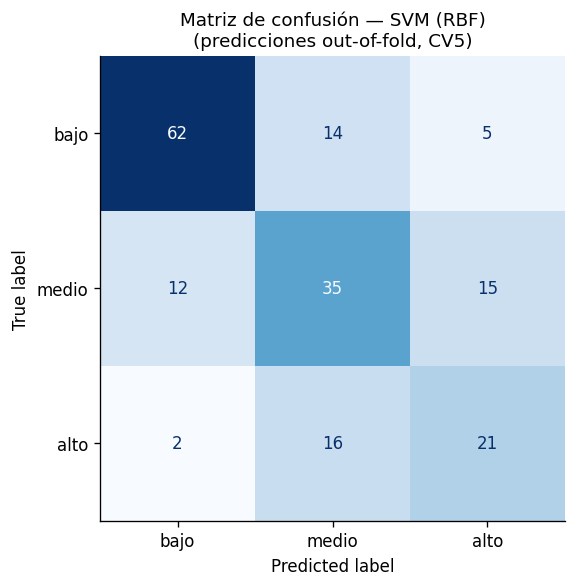

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_display, y_pred_display, labels=CLASES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — {mejor}\n(predicciones out-of-fold, CV5)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 14. Feature importance

### 14.1 Random Forest — Mean Decrease in Impurity (MDI)

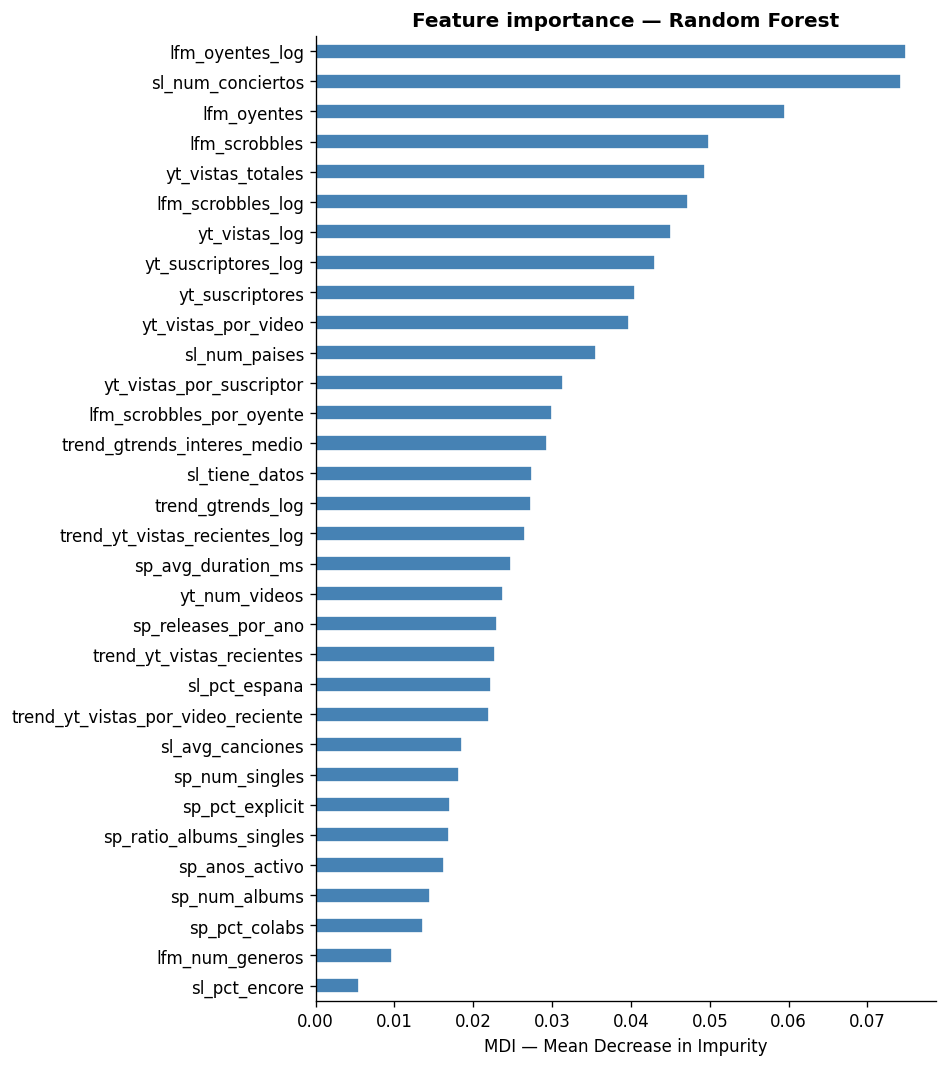

In [15]:
rf.fit(X_arbol, y)
importancias_rf = pd.Series(rf.feature_importances_, index=feat_arbol).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importancias_rf.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('MDI — Mean Decrease in Impurity')
ax.set_title('Feature importance — Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png', bbox_inches='tight')
plt.show()

### 14.2 XGBoost — Gain

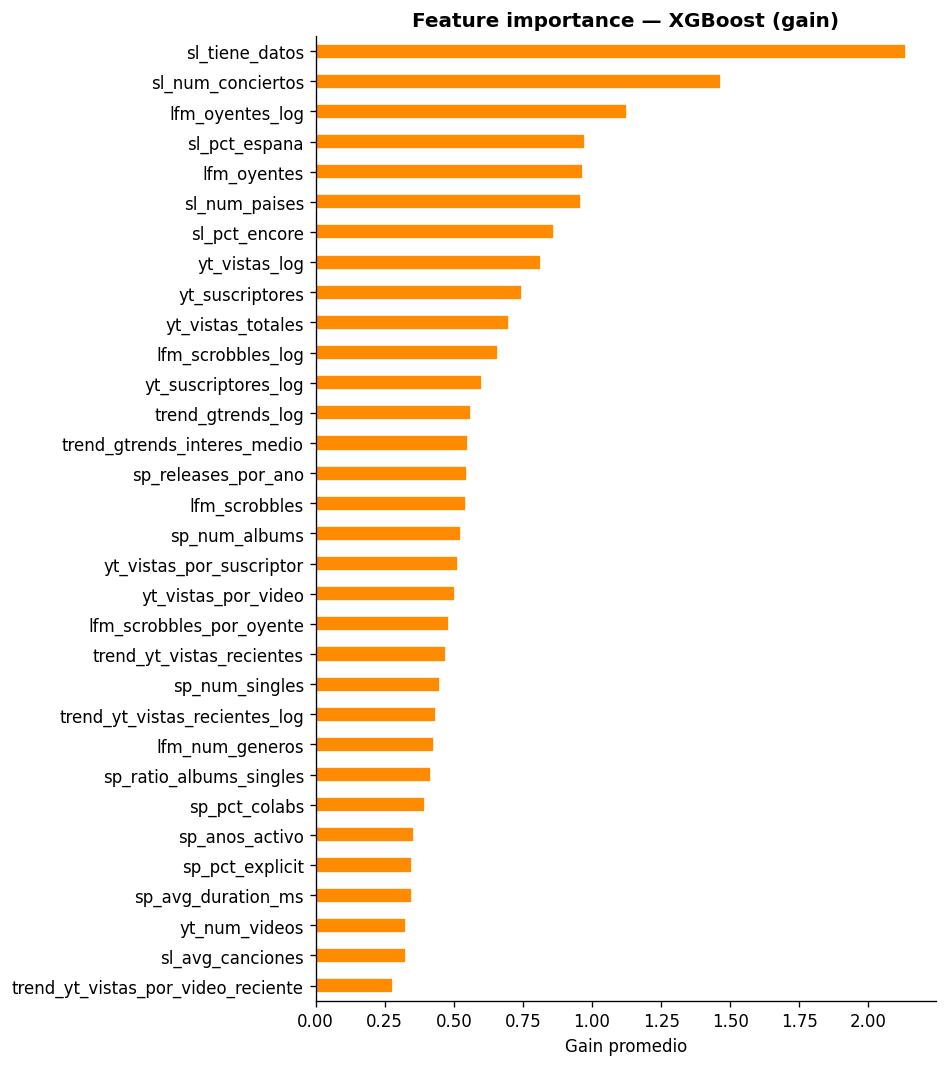

In [16]:
xgb.fit(X_arbol, y_xgb)
importancias_xgb = pd.Series(
    xgb.get_booster().get_score(importance_type='gain'),
    name='gain'
).reindex(feat_arbol).fillna(0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importancias_xgb.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Gain promedio')
ax.set_title('Feature importance — XGBoost (gain)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_xgb.png', bbox_inches='tight')
plt.show()

### 14.3 Top-10 features — RF vs XGBoost

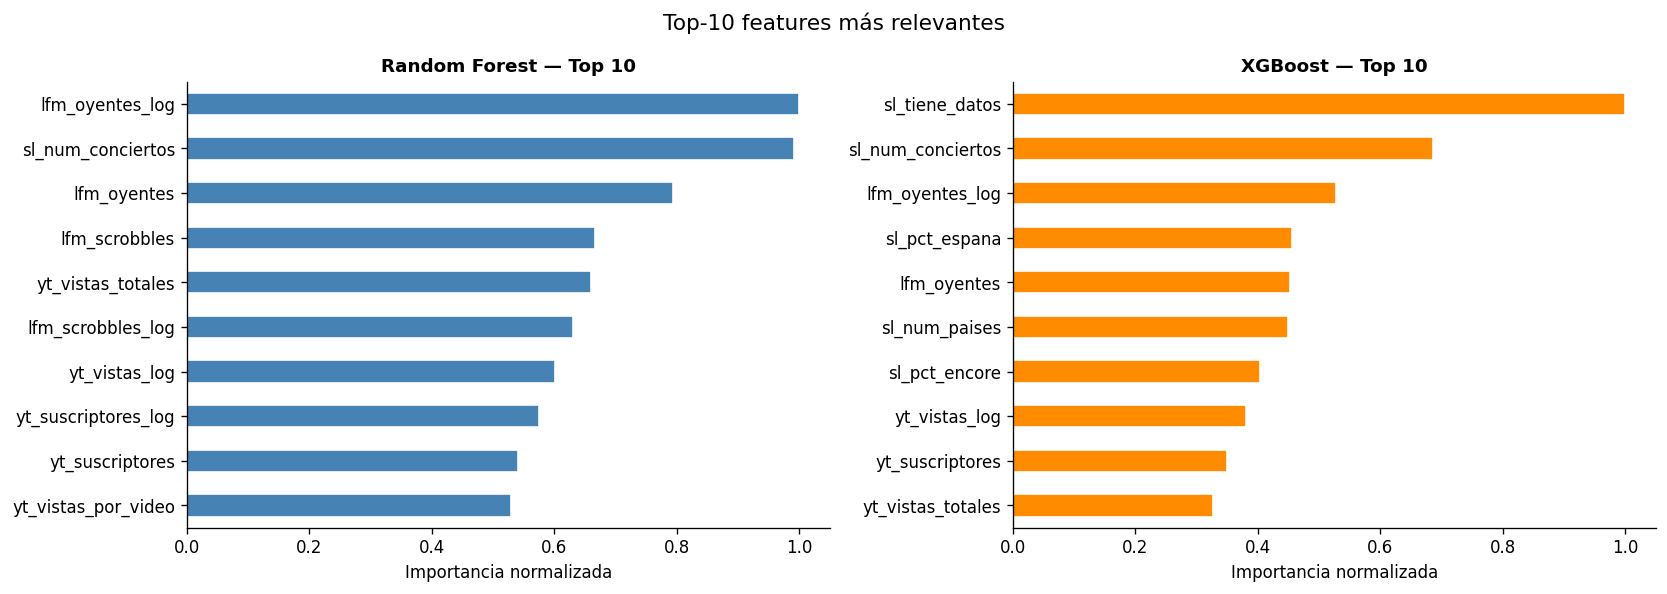

In [17]:
top_n = 10
rf_top  = importancias_rf.head(top_n)
xgb_top = importancias_xgb.head(top_n)

# Normalizar a escala 0-1 para comparación visual
rf_norm  = rf_top  / rf_top.max()
xgb_norm = xgb_top / xgb_top.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, importancia, titulo, color in [
    (axes[0], rf_norm,  'Random Forest — Top 10', 'steelblue'),
    (axes[1], xgb_norm, 'XGBoost — Top 10',       'darkorange'),
]:
    importancia.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Importancia normalizada')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

plt.suptitle('Top-10 features más relevantes', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_top10.png', bbox_inches='tight')
plt.show()

## 15. Análisis de errores — ¿Dónde falla el mejor modelo?

Analizamos los artistas que el modelo clasifica incorrectamente en CV para entender si hay patrones sistemáticos.

In [18]:
df_raw = pd.read_csv('../data/processed/artist_features.csv')

# Reutilizar y_oof calculado en la sección 11 — mismas predicciones OOF
errores = df_raw[['nombre_buscado', 'nivel']].copy()
errores['pred_cv'] = y_pred_display.values
errores['correcto'] = errores['nivel'] == errores['pred_cv']

print(f'Artistas mal clasificados en CV ({mejor}): {(~errores.correcto).sum()} / {len(errores)}')
print(f'Accuracy CV estimada: {errores.correcto.mean():.1%}')
print()
print('Artistas con error de clasificación:')
print(errores[~errores.correcto][['nombre_buscado', 'nivel', 'pred_cv']].to_string(index=False))

Artistas mal clasificados en CV (SVM (RBF)): 64 / 182
Accuracy CV estimada: 64.8%

Artistas con error de clasificación:
      nombre_buscado nivel pred_cv
              Tarchi  bajo   medio
                Guxo medio    bajo
    ladiferencia2006 medio    bajo
                Dano medio    alto
               LEÏTI medio    alto
             Biberon  bajo    alto
                 Mda medio    alto
            Choclock  alto   medio
          WEST DUBAI medio    bajo
                Ayax medio    alto
           LaBlackie  alto   medio
             Metrika  alto   medio
           Oddliquor medio    bajo
               Rojuu medio    alto
            Ergo Pro medio    bajo
          Sara Socas  alto    bajo
               KG970  bajo   medio
         Samuel SLZR  bajo   medio
         John Pollõn medio    bajo
        Shoda Monkas  bajo    alto
              Albany  alto   medio
           vatocholo  alto    bajo
          Raul Clyde  alto   medio
                mvrk  alto   medio
     

In [19]:
# Tipos de error: ¿confunde bajo-medio o medio-alto?
errores_solo = errores[~errores.correcto].copy()
errores_solo['par_error'] = errores_solo['nivel'] + ' → ' + errores_solo['pred_cv']
print('Pares de error más frecuentes:')
print(errores_solo['par_error'].value_counts().to_string())

Pares de error más frecuentes:
par_error
alto → medio    16
medio → alto    15
bajo → medio    14
medio → bajo    12
bajo → alto      5
alto → bajo      2


## 16. Conclusiones

### Resultados (StratifiedKFold k=5, 182 artistas)

| Modelo | Accuracy | F1 macro | Estabilidad (std) |
|--------|----------|----------|-------------------|
| Dummy most_frequent | 44.5% ± 0.9% | 20.5% ± 0.3% | — |
| Dummy stratified | 38.4% ± 8.3% | 31.4% ± 6.0% | — |
| Regresión Logística | 59.4% ± 7.5% | 56.3% ± 8.1% | ⚠️ variable |
| Regresión Ordinal (mord) | 60.4% ± 4.9% | 56.4% ± 4.5% | ✅ estable |
| LightGBM | 61.0% ± 5.7% | 57.6% ± 5.0% | ✅ estable |
| Random Forest | 61.6% ± 3.2% | 58.5% ± 3.5% | ✅ muy estable |
| XGBoost | 63.2% ± 3.9% | 60.3% ± 3.7% | ✅ estable |
| **SVM (RBF)** | **64.8% ± 7.6%** | **62.3% ± 8.0%** | ⚠️ variable |

### Interpretación de los nuevos modelos

**Regresión Ordinal (mord):** alcanza 60.4% acc — supera a LR en estabilidad con varianza similar. La hipótesis ordinal (bajo < medio < alto) aporta señal real. Sin embargo, no puede competir con los ensembles de árboles.

**LightGBM:** resultado sólido (61.0% acc, 57.6% F1) con buena estabilidad (±5.0%), pero queda por detrás de Random Forest y XGBoost en ambas métricas.

### Ranking final y candidatos para tuning

1. **SVM (RBF)** — mejor F1 (62.3%) aunque con mayor varianza (±8.0%). El kernel RBF captura relaciones no lineales de forma efectiva con el escalado RobustScaler.
2. **XGBoost** — segundo en F1 (60.3%) con buena estabilidad (±3.7%). **Candidato prioritario al tuning**: si se estabiliza y mejora, puede superar a SVM.
3. **Random Forest** — tercero en F1 (58.5%) pero el más robusto de todos (±3.2%). Candidato secundario: modelo fiable de referencia.
4. LightGBM y Ordinal quedan como candidatos de respaldo.

> Dado el solapamiento de intervalos (SVM ±8.0% vs XGBoost ±3.7%), **XGBoost podría ser más fiable en producción** a pesar de una media ligeramente inferior. El tuning de hiperparámetros resolverá este dilema: si XGBoost alcanza o supera a SVM en media con menor varianza, será el modelo final.

### Análisis de errores (SVM OOF, 182 artistas)

- **64/182 mal clasificados** (64.8% accuracy OOF)
- **bajo**: F1=0.79 — bien clasificada. La baja presencia digital es una señal clara.
- **medio**: F1=0.55 — la más difícil. Errores simétricos hacia ambos lados. Es la clase fronteriza por definición.
- **alto**: F1=0.53, recall moderado. Artistas con presencia digital moderada que el modelo infravalora.

| Par de error | Frecuencia |
|---|---|
| alto → medio | 16 |
| medio → alto | 15 |
| bajo → medio | 14 |
| medio → bajo | 12 |
| bajo → alto | 5 |
| alto → bajo | 2 |

Los errores de 2 saltos (alto→bajo, bajo→alto) son minoritarios (7 casos), lo que confirma que el modelo respeta la ordinalidad implícitamente aunque no esté diseñado para ello.

### Feature importance (RF y XGBoost — consenso)

1. **`sl_num_conciertos`** — #1 en ambos modelos. ⚠️ 41% de NaN imputados como 0: posible señal espuria (0 = bajo por defecto).
2. **`lfm_oyentes`** — correlación Spearman +0.63, señal más limpia del dataset.
3. **`yt_vistas_totales` / `yt_suscriptores`** — volumen digital acumulado.
4. **`sl_num_paises`** / **`lfm_scrobbles`** — alcance geográfico y engagement histórico.

Las features de tendencias recientes (Google Trends, YouTube reciente) tienen importancia secundaria — complementan pero no dominan.

### Limitaciones

- **n=182**: varianza de CV todavía notable. Diferencias < 3 puntos entre modelos próximos no son estadísticamente significativas.
- **Imputación de setlist.fm**: 41% con 0 conciertos puede crear señal espuria en `sl_num_conciertos`.
- **Datos de punto fijo**: snapshot temporal, no captura artistas en trayectoria ascendente/descendente.
- **Spotify bloqueado**: sin `popularity` ni `audio_features`.
- **Etiquetado semisupervisado**: ~50% de etiquetas asignadas manualmente, especialmente en la frontera bajo-medio.

### Próximos pasos

1. **`03_hiperparametros.ipynb`**: `RandomizedSearchCV` sobre XGBoost. Objetivo: estabilizar XGBoost y buscar mejora real que permita comparar con SVM en igualdad de condiciones.
2. **Investigar `sl_num_conciertos`**: probar imputación por mediana de nivel en lugar de 0 — si su importancia cae, la señal era espuria.
3. **`src/models/train.py`**: entrenar el modelo final sobre todos los datos y serializar con `joblib`.
4. **Dashboard Streamlit**: integrar predicciones interactivas.